In [16]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline


In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [23]:
def check_data_structure(base_dir='chest_xray'):
  base_path = Path(base_dir)
  if not base_path.exists():
    print(f"{base_path} does not exist")
    return False

  required_dirs = {
      'train': ['NORMAL', 'PNEUMONIA'],
      'test': ['NORMAL', 'PNEUMONIA']
  }
  all_ok = True

  for split, classes in required_dirs.items():
    split_path = base_path / split
    if not split_path.exists():
      print(f"{split_path} does not exist")
      all_ok = False
      continue

    for class_name in classes:
      class_path = split_path / class_name
      if not class_path.exists():
        print(f"{class_path} does not exist")
        all_ok = False
      else:
        image_files = list(class_path.glob('*.jpeg')) + list(class_path.glob('*.jpg')) + list(class_path.glob('*.png'))
        count = len(image_files)
        print(f"{class_path} has {count} images")
        if count == 0:
          print(f"No images found in {class_path}")
        else:
          print(f"{class_name} - {count} images")

  return all_ok

check_data_structure("/kaggle/input/chest-xray-pneumonia/chest_xray")

/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL has 1341 images
NORMAL - 1341 images
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA has 3875 images
PNEUMONIA - 3875 images
/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL has 234 images
NORMAL - 234 images
/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA has 390 images
PNEUMONIA - 390 images


True

In [25]:
IMG_SIZE = 224
IMG_CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 20

BASE_DIR = Path("/kaggle/input/chest-xray-pneumonia")
DATA_DIR = BASE_DIR / "chest_xray"

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
VAL_DIR = DATA_DIR / "val"

Train set counts: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Class PNEUMONIA has 3875 images
Class NORMAL has 1341 images


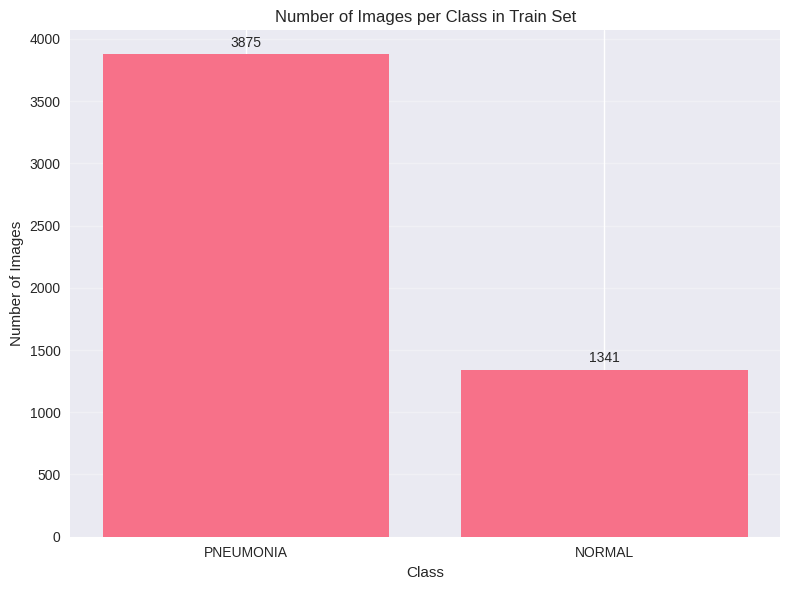

In [28]:
def count_images(directory):
  counts = {}
  if os.path.exists(directory):
    for class_name in os.listdir(directory):
      class_dir = os.path.join(directory, class_name)
      if os.path.isdir(class_dir):
        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        counts[class_name] = len(image_files)
  return counts

if os.path.exists(TRAIN_DIR):
  train_counts = count_images(TRAIN_DIR)
  print("Train set counts:", train_counts)

  for class_name, count in train_counts.items():
    print(f"Class {class_name} has {count} images")

  plt.figure(figsize=(8, 6))
  classes = list(train_counts.keys())
  counts = list(train_counts.values())
  plt.bar(classes, counts)
  plt.xlabel('Class')
  plt.ylabel('Number of Images')
  plt.grid(axis='y', alpha=0.3)
  plt.title('Number of Images per Class in Train Set')
  for i, v in enumerate(counts):
    plt.text(i, v + max(counts)*0.01, str(v), ha='center', va='bottom')
  plt.tight_layout()
  plt.show()
else:
  print(f"{TRAIN_DIR} does not exist")

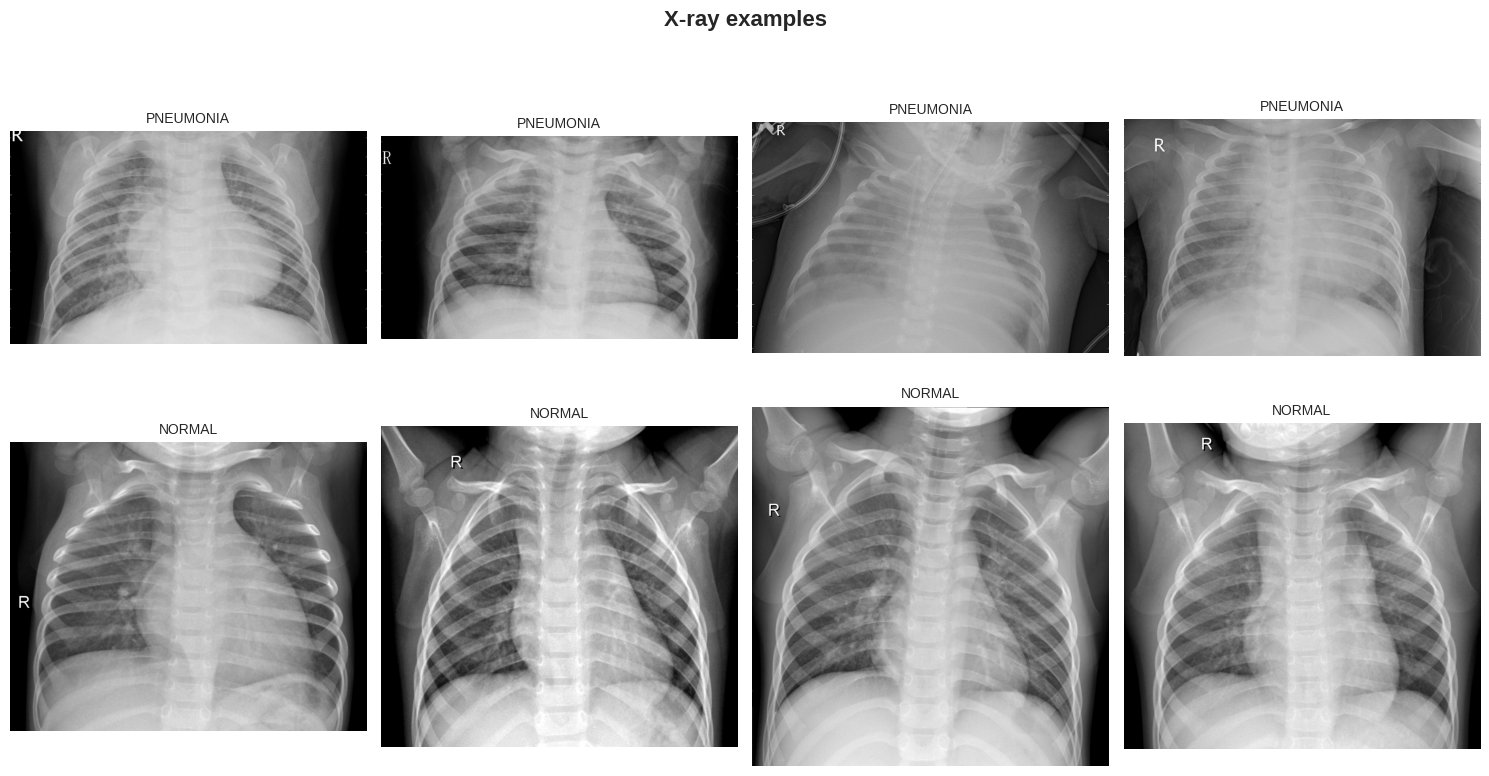

In [29]:
def visualize_samples(directory, num_samples=4):
    if not os.path.exists(directory):
        print(f"Directory {directory} not found")
        return

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 8))
    fig.suptitle('X-ray examples', fontsize=16, fontweight='bold')

    classes = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]

    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(directory, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Выбираем случайные примеры
        sample_files = np.random.choice(image_files,
                                       min(num_samples, len(image_files)),
                                       replace=False)

        for img_idx, img_file in enumerate(sample_files):
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[class_idx, img_idx].imshow(img, cmap='gray')
            axes[class_idx, img_idx].set_title(f'{class_name}', fontsize=10)
            axes[class_idx, img_idx].axis('off')

    plt.tight_layout()
    plt.show()

if os.path.exists(TRAIN_DIR):
    visualize_samples(TRAIN_DIR, num_samples=4)

## Data Augmentation

[Data Augmentation](https://habr.com/ru/companies/smartengines/articles/264677/)

In [30]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

### Архитектура нашей модели:

1. Сверточные слои (Conv2D)
2. Слои пуллинга (MaxPooling2D)
3. Batch normalization
4. Dropout
5. Dense

[CNN](https://learnopencv.com/understanding-convolutional-neural-networks-cnn/)

In [32]:
def create_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)):
    model = Sequential([
            Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding="same"),
            BatchNormalization(),
            Conv2D(32, (3, 3), activation='relu', padding="same"),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),

            Conv2D(64, (3, 3), activation='relu',input_shape=input_shape, padding="same"),
            BatchNormalization(),
            Conv2D(64, (3, 3), activation='relu', padding="same"),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),

            Conv2D(128, (3, 3), activation='relu', input_shape=input_shape, padding="same"),
            BatchNormalization(),
            Conv2D(128, (3, 3), activation='relu', padding="same"),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),

            Conv2D(256, (3, 3), activation='relu', input_shape=input_shape, padding="same"),
            BatchNormalization(),
            Conv2D(256, (3, 3), activation='relu', padding="same"),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),

            Flatten(),

            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),

            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),

            Dense(1, activation='sigmoid')
            ])
    return model

model = create_cnn_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 26,999,457 (102.99 MB)

 Trainable params: 26,996,961 (102.99 MB)

 Non-trainable params: 2,496 (9.75 KB)

## Компиляция модели

In [39]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', "precision", 'recall']
)

## Callbacks

1. Early stopping
2. ReduceLROnPlateau
3. ModelCheckpoint

In [40]:
os.makedirs('models', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=0.00001),
    ModelCheckpoint(filepath='models/best_model.h5', monitor='val_loss', save_best_only=True,mode='max', verbose=1)]

In [41]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    color_mode='rgb'
)

validation_generator = validation_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    color_mode='rgb'
)


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [42]:
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = None

if validation_generator:
  validation_steps = validation_generator.samples // BATCH_SIZE
else:
  validation_steps = test_generator.samples // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print("Start training")


history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs = EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)
print("Training finished")

Steps per epoch: 163
Validation steps: 0
Start training
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.6317 - loss: 0.7977 - precision: 0.8487 - recall: 0.6104
Epoch 1: val_loss improved from None to 2.28696, saving model to models/best_model.h5



Epoch 1: finished saving model to models/best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.6984 - loss: 0.6702 - precision: 0.9008 - recall: 0.6676 - val_accuracy: 0.5000 - val_loss: 2.2870 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.8059 - loss: 0.4870 - precision: 0.9555 - recall: 0.7764
Epoch 2: val_loss improved from 2.28696 to 2.94133, saving model to models/best_model.h5



Epoch 2: finished saving model to models/best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 822ms/step - accuracy: 0.8165 - loss: 0.4631 - precision: 0.9528 - recall: 0.7923 - val_accuracy: 0.5000 - val_loss: 2.9413 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.8419 - loss: 0.3985 - precision: 0.9546 - recall: 0.8271
Epoch 3: val_loss improved from 2.94133 to 3.32423, saving model to models/best_model.h5



Epoch 3: finished saving model to models/best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 777ms/step - accuracy: 0.8526 - loss: 0.3936 - precision: 0.9501 - recall: 0.8459 - val_accuracy: 0.5000 - val_loss: 3.3242 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.8748 - loss: 0.3325 - precision: 0.9468 - recall: 0.8798
Epoch 4: val_loss did not improve from 3.32423
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 794ms/step - accuracy: 0.8698 - loss: 0.3487 - precision: 0.9496 - recall: 0.8710 - val_accuracy: 0.5000 - val_loss: 2.0373 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.8858 - loss: 0.3033 - precision: 0.9523 - recall: 0.8921
Epoch 5: val_loss did not improve from 3.32423
163/163 ━━━━━━━━━━━━━━━━━━━━ 147s 903ms/step - accuracy: 0.8907 - loss: 0.2985 - precision: 0.9514 - recall: 0.8988 - val_accuracy: 0.5625


Epoch 16: finished saving model to models/best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 150s 775ms/step - accuracy: 0.9367 - loss: 0.1876 - precision: 0.9591 - recall: 0.9556 - val_accuracy: 0.4375 - val_loss: 4.3623 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-05
Epoch 17/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.9376 - loss: 0.1718 - precision: 0.9633 - recall: 0.9535
Epoch 17: val_loss did not improve from 4.36234
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 722ms/step - accuracy: 0.9358 - loss: 0.1787 - precision: 0.9578 - recall: 0.9556 - val_accuracy: 0.6875 - val_loss: 0.8000 - val_precision: 0.8000 - val_recall: 0.5000 - learning_rate: 2.5000e-05
Epoch 18/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.9368 - loss: 0.1940 - precision: 0.9625 - recall: 0.9514
Epoch 18: val_loss did not improve from 4.36234
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 728ms/step - accuracy: 0.9392 - loss: 0.1887 - precision: 0.9628 - recall: 0.9551 - val_acc

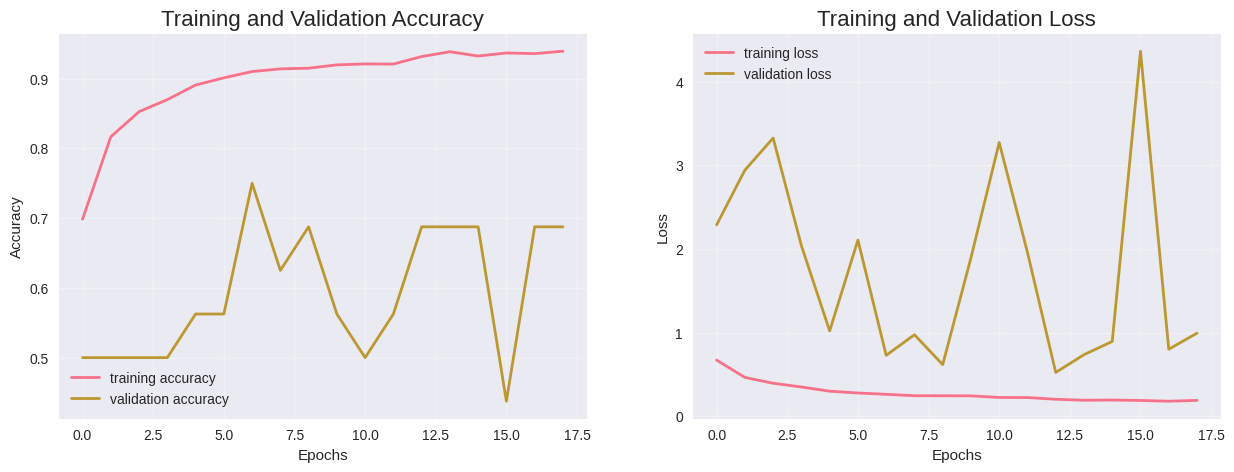

Model final metrics
Accuracy: 0.9392
Validation accuracy: 0.6875
Loss: 0.1887
Validation loss: 0.9921


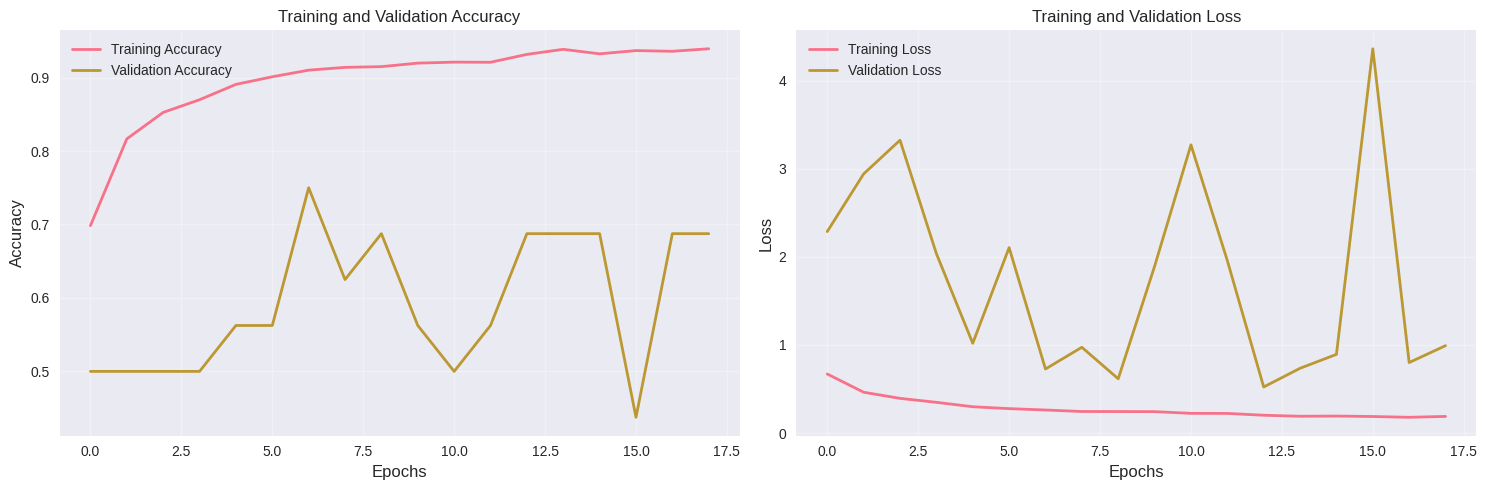

Model final metrics
Accuracy: 0.9392
Validation Accuracy: 0.6875
Loss: 0.1887
Validation Loss: 0.9921


In [44]:
from matplotlib import axes
def plot_training_history(history):
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  # Accuracy
  axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
  axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
  axes[0].set_title('Training and Validation Accuracy', fontsize=12)
  axes[0].set_xlabel('Epochs', fontsize=12)
  axes[0].set_ylabel('Accuracy', fontsize=12)
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  # Loss
  axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
  axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
  axes[1].set_title('Training and Validation Loss', fontsize=12)
  axes[1].set_xlabel('Epochs', fontsize=12)
  axes[1].set_ylabel('Loss', fontsize=12)
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

  print("Model final metrics")
  print("=" * 50)
  print(f"Accuracy: {history.history['accuracy'][-1]:.4f}")
  print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
  print(f"Loss: {history.history['loss'][-1]:.4f}")
  print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")

plot_training_history(history)



20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 391ms/step
NORMAL = 0
PNEUMONIA = 1


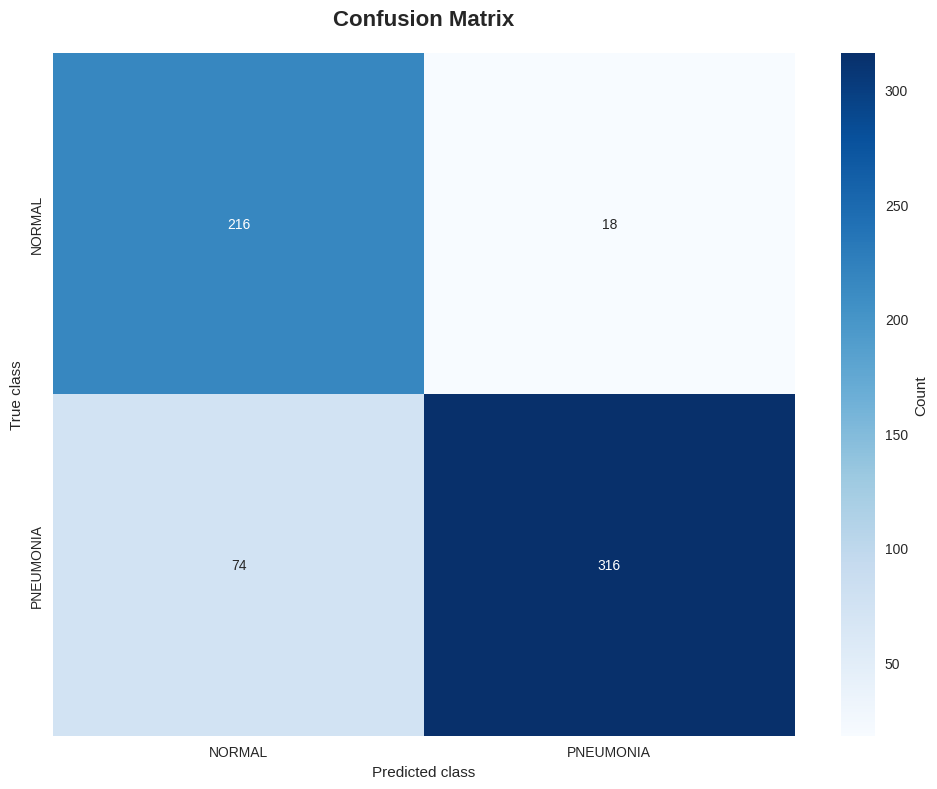

Confusion Matrix:
       Predicted
      NORMAL  PNEUMONIA
True  NORMAL: 216  18
      PNEUMONIA: 74  316
True positives (TP): 316 - true predicted PNEUMONIA
True negatives (TN): 216 - true predicted NORMAL
False positives (FP): 18 - false predicted PNEUMONIA
False negatives (FN): 74 - false predicted NORMAL
Accuracy: 0.8526
Precision NORMAL: 0.7448
Precision PNEUMONIA: 0.9461
Recall NORMAL: 0.9231
Recall PNEUMONIA: 0.8103
F1 score NORMAL: 0.8244
F1 score PNEUMONIA: 0.8729


In [45]:
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = (predictions> 0.5).astype(int).flatten()
true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(f"{class_names[0]} = 0")
print(f"{class_names[1]} = 1")

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print("       Predicted")
print(f"      {class_names[0]}  {class_names[1]}")
print(f"True  {class_names[0]}: {cm[0][0]}  {cm[0][1]}")
print(f"      {class_names[1]}: {cm[1][0]}  {cm[1][1]}")

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print(f"True positives (TP): {TP} - true predicted {class_names[1]}")
print(f"True negatives (TN): {TN} - true predicted {class_names[0]}")
print(f"False positives (FP): {FP} - false predicted {class_names[1]}")
print(f"False negatives (FN): {FN} - false predicted {class_names[0]}")

accuracy = accuracy_score(true_classes, predicted_classes)
precision_0 = TN/(TN+FN) if TN+FN > 0 else 0
precision_1 = TP/(TP+FP) if TP+FP > 0 else 0
recall_0 = TN/(TN+FP) if TN+FP > 0 else 0
recall_1 = TP/(TP+FN) if TP+FN > 0 else 0

f1_0 = 2 * (precision_0 * recall_0) / (precision_0 + recall_0) if precision_0 + recall_0 > 0 else 0
f1_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if precision_1 + recall_1 > 0 else 0

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision {class_names[0]}: {precision_0:.4f}")
print(f"Precision {class_names[1]}: {precision_1:.4f}")
print(f"Recall {class_names[0]}: {recall_0:.4f}")
print(f"Recall {class_names[1]}: {recall_1:.4f}")
print(f"F1 score {class_names[0]}: {f1_0:.4f}")
print(f"F1 score {class_names[1]}: {f1_1:.4f}")